In [89]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

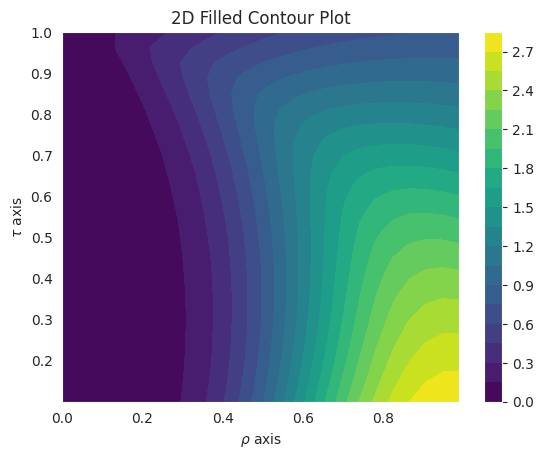

<Figure size 640x480 with 0 Axes>

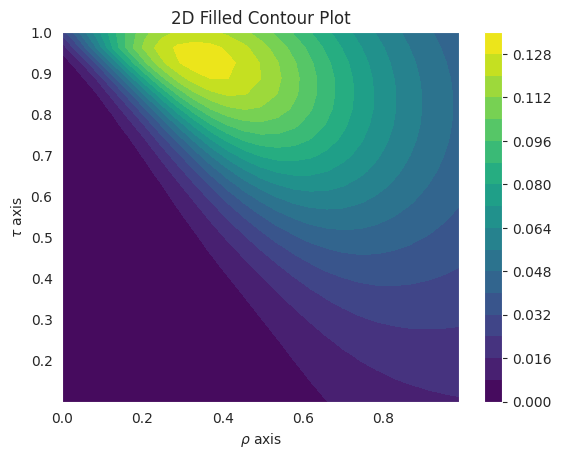

<Figure size 640x480 with 0 Axes>

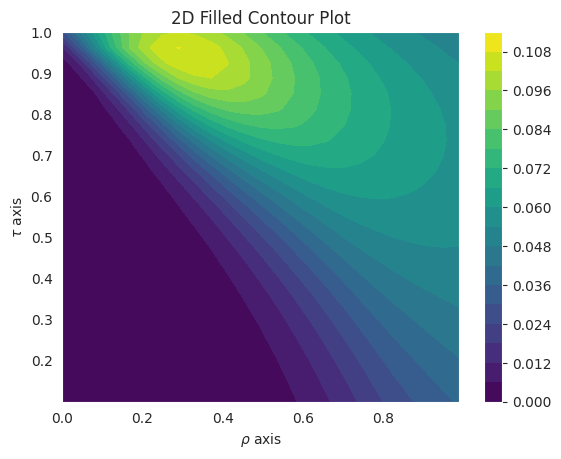

<Figure size 640x480 with 0 Axes>

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

rho_grid = jnp.linspace(0, 0.99, 25)
tau_grid = jnp.linspace(0.1, 1, 25)

def plot_3D(x, y, arr):
    # Assume arr is your n x n array
    X, Y = np.meshgrid(x, y)
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the surface
    ax.plot_surface(X, Y, arr, cmap='viridis')  # you can change the colormap
    ax.set_xlabel(r'$\rho$ axis')
    ax.set_ylabel(r'$\tau$ axis')
    ax.set_zlabel('Z axis (array values)')
    ax.view_init(elev=30, azim=135)
    
    plt.show()

def plot_contour2D(x, y, arr):
    X, Y = np.meshgrid(x, y)
    
    plt.figure()
    cf = plt.contourf(X, Y, arr, levels=20, cmap='viridis')
    plt.xlabel(r'$\rho$ axis')
    plt.ylabel(r'$\tau$ axis')
    plt.title('2D Filled Contour Plot')
    plt.colorbar(cf)  # Show color scale
    plt.show()


idx = 1
t = PKLs[idx]['res'][5].shape[1]
vals = PKLs[idx]['res'][5].mean(axis=0).reshape((t, 25, 25))
for idx in np.arange(0, vals.shape[0], 5):
    arr = vals[idx]
    plot_contour2D(rho_grid, tau_grid, arr)
    plt.clf()
    

In [90]:
PKL_titles

['config_dim4_ess_exp_ar_rw_uncoupled.py_04042425113056.pkl',
 'config_dim2_exp_ar_rw_uncoupled.py_04042425104602.pkl',
 'config_dim4_exp_ar_rw_uncoupled.py_04042425105140.pkl',
 'config_dim4_ess_exp_ar_rw_uncoupled.py_04042425110548.pkl']

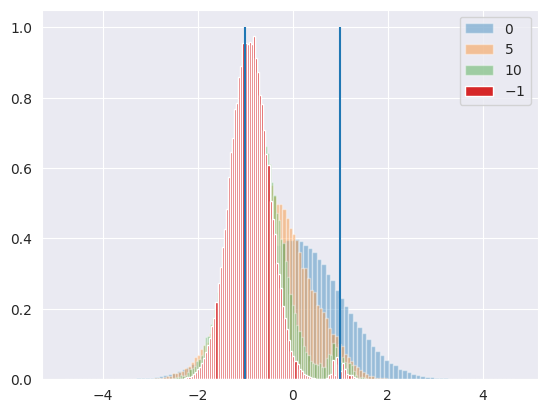

In [77]:
idx=2
for t in np.concatenate([np.arange(0, PKLs[idx]['res'][0].shape[1], 5), [-1]]):
    if t == -1:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=1, density=True, label=rf"${-1}$")
    else:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=0.4, density=True, label=rf"${t}$")
plt.legend()
plt.vlines(x=1, ymin=0, ymax=1)
plt.vlines(x=-1, ymin=0, ymax=1)

In [48]:
np.concatenate([np.arange(0, PKLs[idx]['res'][0].shape[1], 5), [-1]])

array([ 0,  5, 10, -1])

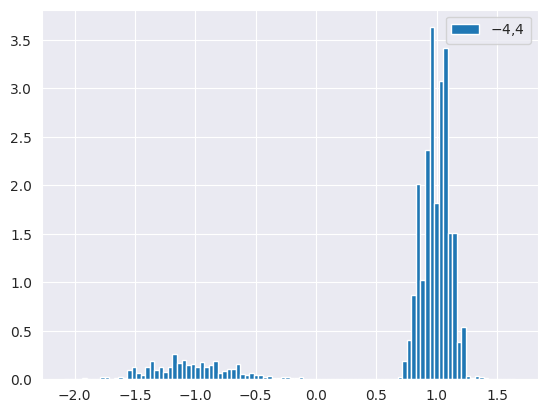

<Figure size 640x480 with 0 Axes>

In [88]:
def get_hist(idx, dim, t):
    if dim == -1:
        plt.hist(PKLs[idx]['res'][0][:,t,0,...].reshape(-1), bins=100, alpha=1, density=True, label=rf"${t}$")
    else:
        plt.hist(PKLs[idx]['res'][0][:,t,0,..., dim].reshape(-1), bins=100, alpha=1, density=True, label=rf"${t}$,${dim+1}$")
    plt.legend()
    plt.show()
    plt.clf()
get_hist(0, 3, -4)

In [82]:
PKLs[idx]['res'][0][:,0,..., 0]

Array([[[[ 0.19580325, -0.812666  , -0.5713493 , ..., -0.6114302 ,
          -0.8957666 , -1.3322461 ],
         [ 1.7508514 ,  0.69447744, -0.41968828, ...,  0.389434  ,
           1.6868246 ,  0.25306028],
         [ 0.8884198 , -0.35980946, -0.8759866 , ..., -0.53943014,
          -0.18095039,  0.8845997 ],
         ...,
         [-0.7736895 , -0.06636036, -1.1156082 , ..., -0.9201097 ,
           0.7608139 , -1.9783263 ],
         [-0.9592142 , -0.20361839, -0.7590209 , ..., -0.30470562,
          -0.44258124,  0.5816547 ],
         [-0.07291248,  0.50873435, -1.7755713 , ...,  1.8772061 ,
          -0.12436406, -1.9813466 ]],

        [[-0.14144824,  1.5328115 ,  0.30159372, ..., -1.2976968 ,
          -0.29598844,  1.1630797 ],
         [-1.170297  ,  0.6117838 ,  0.48521137, ...,  1.697433  ,
          -1.3242341 , -0.86442715],
         [-0.11872397,  1.3063914 ,  0.51641244, ..., -0.99244666,
           0.11332089, -1.5290926 ],
         ...,
         [ 0.41716376,  0.9578917 

In [61]:
PKLs[idx]['res'][6]

Array([[0.05350586, 0.10740402, 0.20531887, 0.3440556 , 0.530681  ,
        0.7685463 , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        ]], dtype=float32)